In [1]:
import sqlite3
import pandas as pd

In [6]:
conn = sqlite3.connect("C:\\Users\\Harshitha\\OneDrive\\Desktop\\Retail-Intelligence-Platform\\database\\retail.db")
print("Database Connected Successfully!")

Database Connected Successfully!


In [7]:
query = "SELECT * FROM sales"

df = pd.read_sql_query(query, conn)

df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2011-01-07 00:00:00.000,CA-2011-130813,High,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2011-01-21 00:00:00.000,CA-2011-148614,Medium,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05 00:00:00.000,CA-2011-118962,Medium,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05 00:00:00.000,CA-2011-118962,Medium,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2011-09-29 00:00:00.000,CA-2011-146969,High,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [8]:
print(df.shape)

(51290, 26)


In [9]:
query = """
SELECT SUM(Sales) AS Total_Sales
FROM sales
"""

sales = pd.read_sql_query(query, conn)

print(sales)

   Total_Sales
0     12642905


In [10]:
query = """
SELECT SUM(Profit) AS Total_Profit
FROM sales
"""

profit = pd.read_sql_query(query, conn)

print(profit)

   Total_Profit
0  1.467457e+06


In [11]:
query = """
SELECT Category,
SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Category
"""

category = pd.read_sql_query(query, conn)

print(category)

          Category  Total_Sales
0        Furniture      4110884
1  Office Supplies      3787330
2       Technology      4744691


In [15]:
query = """
SELECT "Product.Name",
SUM(Sales) AS Sales
FROM sales
GROUP BY "Product.Name"
ORDER BY Sales DESC
LIMIT 10
"""

top_products = pd.read_sql_query(query, conn)

print(top_products)

                                        Product.Name  Sales
0                       Apple Smart Phone, Full Size  86936
1                       Cisco Smart Phone, Full Size  76441
2                    Motorola Smart Phone, Full Size  73159
3                       Nokia Smart Phone, Full Size  71904
4              Canon imageCLASS 2200 Advanced Copier  61600
5         Hon Executive Leather Armchair, Adjustable  58200
6  Office Star Executive Leather Armchair, Adjust...  50667
7  Harbour Creations Executive Leather Armchair, ...  50120
8                      Samsung Smart Phone, Cordless  48654
9                  Nokia Smart Phone, with Caller ID  47880


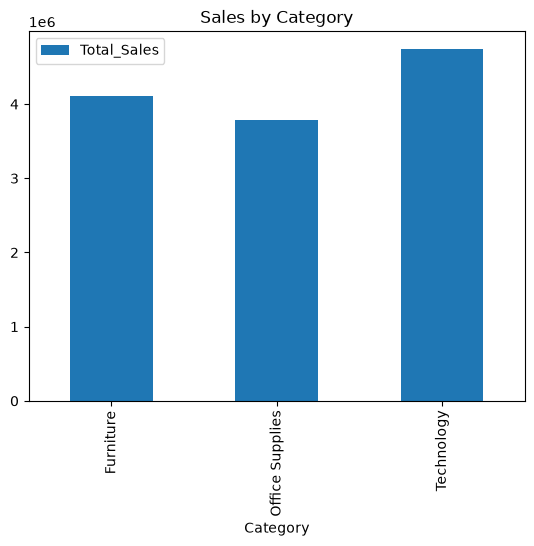

In [16]:
import matplotlib.pyplot as plt

category.plot(
    x="Category",
    y="Total_Sales",
    kind="bar"
)

plt.title("Sales by Category")
plt.show()

In [17]:
conn.close()